In [1]:
# Cell 0 — Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

print("✅ NumPy/Pandas/Matplotlib ready.")


✅ NumPy/Pandas/Matplotlib ready.


In [2]:
# Cell 1 — Data generation with NumPy
# 10 cities × 12 months, values in [-5, 35] °C
temps = np.random.uniform(low=-5.0, high=35.0, size=(10, 12))
print("✅ temps shape:", temps.shape)
temps[:3, :5]  # preview


✅ temps shape: (10, 12)


array([[ 9.98160475, 33.02857226, 24.27975767, 18.94633937,  1.24074562],
       [28.29770563,  3.49356443,  2.27299869,  2.33618039,  7.16968972],
       [13.24279937, 26.40703846,  2.98695129, 15.56937754, 18.69658275]])

In [4]:
# Cell 2 — Convert to Pandas DataFrame with city names and month columns
cities = [f"City {i}" for i in range(1, 11)]
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df = pd.DataFrame(temps, index=cities, columns=months)
print("✅ DataFrame built:", df.shape)
df.head()


✅ DataFrame built: (10, 12)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City 1,9.981605,33.028572,24.279758,18.946339,1.240746,1.239781,-2.676656,29.647046,19.044600,23.322903,-4.176620,33.796394
City 2,28.297706,3.493564,2.272999,2.336180,7.169690,15.990257,12.277801,6.649166,19.474116,0.579754,6.685786,9.654474
City 3,13.242799,26.407038,2.986951,15.569378,18.696583,-3.141983,19.301794,1.820965,-2.397936,32.955421,33.625281,27.335894
City 4,7.184551,-1.093115,22.369321,12.606100,-0.118471,14.807076,-3.624459,31.372816,5.351199,21.500891,7.468443,15.802721
City 5,16.868411,2.394178,33.783385,26.005313,32.579958,30.793094,18.915999,31.874969,-1.460300,2.839314,-3.190908,8.013213


In [5]:
# Cell 3 — Annual average per city + hottest/coldest city
annual_avg = df.mean(axis=1)  # mean across months (columns)
hottest_city = annual_avg.idxmax()
coldest_city = annual_avg.idxmin()

print("Annual average temperatures (°C):")
display(annual_avg.sort_values(ascending=False).round(2).to_frame("avg_temp"))

print(f"\n🔥 Hottest city (annual average): {hottest_city} -> {annual_avg[hottest_city]:.2f} °C")
print(f"❄️ Coldest city (annual average): {coldest_city} -> {annual_avg[coldest_city]:.2f} °C")


Annual average temperatures (°C):


,avg_temp
City 8,17.61
City 5,16.62
City 10,16.41
City 1,15.64
City 3,15.53
City 6,13.82
City 7,13.19
City 9,11.32
City 4,11.14
City 2,9.57



🔥 Hottest city (annual average): City 8 -> 17.61 °C
❄️ Coldest city (annual average): City 2 -> 9.57 °C


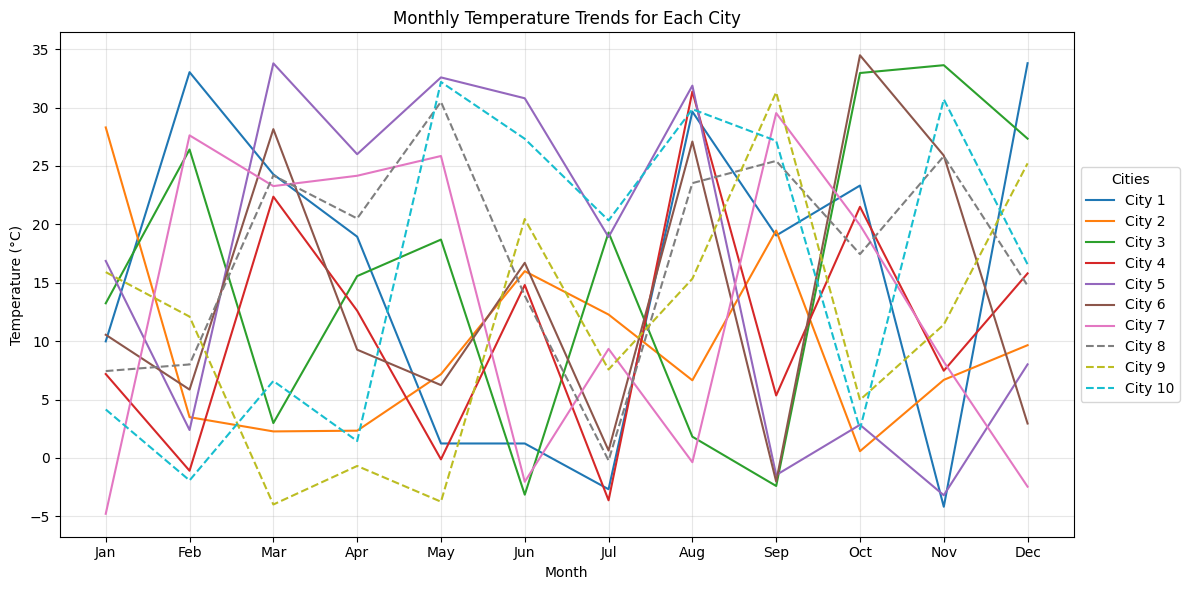

In [6]:
# Cell 4 — Line chart: Monthly temperature trends for each city
plt.figure(figsize=(12, 6))

# Use solid lines for first 7 cities, dashed for last 3 (purely to differentiate)
for i, city in enumerate(df.index):
    ls = "-" if i < 7 else "--"
    plt.plot(months, df.loc[city].values, linestyle=ls, marker=None, label=city)

plt.title("Monthly Temperature Trends for Each City")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Cities")
plt.tight_layout()
plt.show()


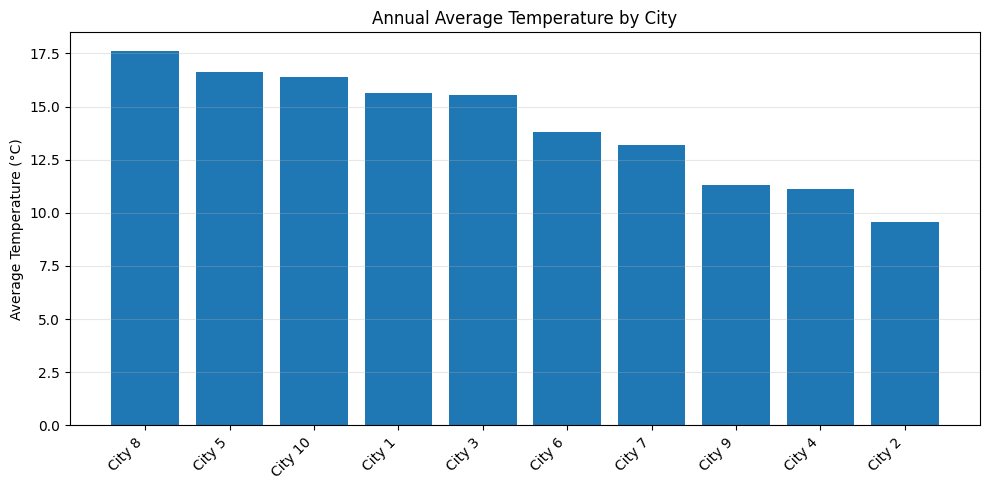

In [7]:
# Cell 5 — Bar chart of annual average temperature by city (sorted)
avg_sorted = annual_avg.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(avg_sorted.index, avg_sorted.values)
plt.title("Annual Average Temperature by City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


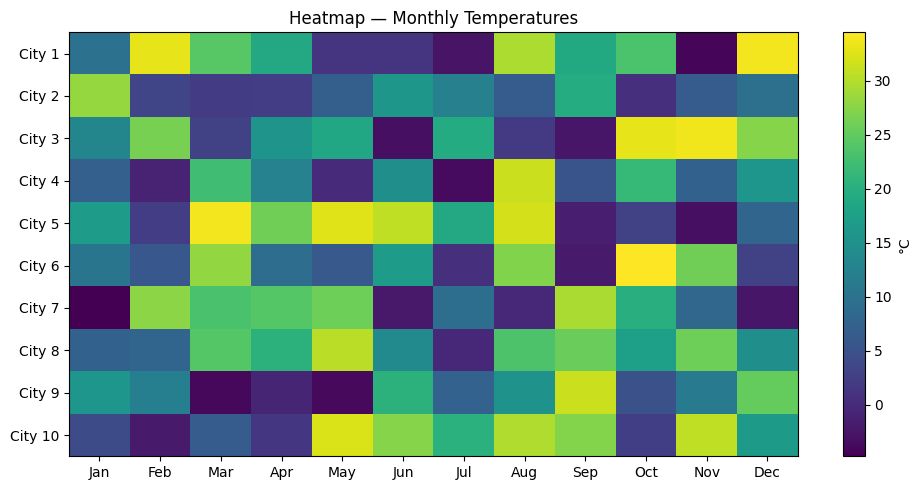

In [8]:
# Cell 6 — Heatmap of monthly temperatures (cities × months)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(df.values, aspect="auto")
ax.set_title("Heatmap — Monthly Temperatures")
ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index)
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months)
plt.colorbar(im, ax=ax, label="°C")
plt.tight_layout()
plt.show()


In [9]:
# Cell 7 — Summary report
print("=== Summary Report ===")
print(f"Hottest city (annual average): {hottest_city} -> {annual_avg[hottest_city]:.2f} °C")
print(f"Coldest city (annual average): {coldest_city} -> {annual_avg[coldest_city]:.2f} °C")
print("""
Observations:
- Monthly trend plot shows variability across cities; some lines stay high (consistently warm), others fluctuate widely.
- Bar chart ranks cities by annual average temperature, making it easy to spot top/bottom performers.
- Heatmap highlights seasonal patterns by city; warmer bands indicate hotter months.
""")


=== Summary Report ===
Hottest city (annual average): City 8 -> 17.61 °C
Coldest city (annual average): City 2 -> 9.57 °C

Observations:
- Monthly trend plot shows variability across cities; some lines stay high (consistently warm), others fluctuate widely.
- Bar chart ranks cities by annual average temperature, making it easy to spot top/bottom performers.
- Heatmap highlights seasonal patterns by city; warmer bands indicate hotter months.

